# HOMEWORK 8

In this homework you are going to implement your first machine learning algorithm to automatically binarize document images. The goal of document binarization is to seprate the characters (letters) from everything else. This is the crucial part for automatic document understanding and information extraction from the . In order to do so, you will use the Otsu thresholding algorithm.

At the end of this notebook, there are a couple of questions for you to answer.

In [1]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

Let's load the document image we will be working on in this homework.

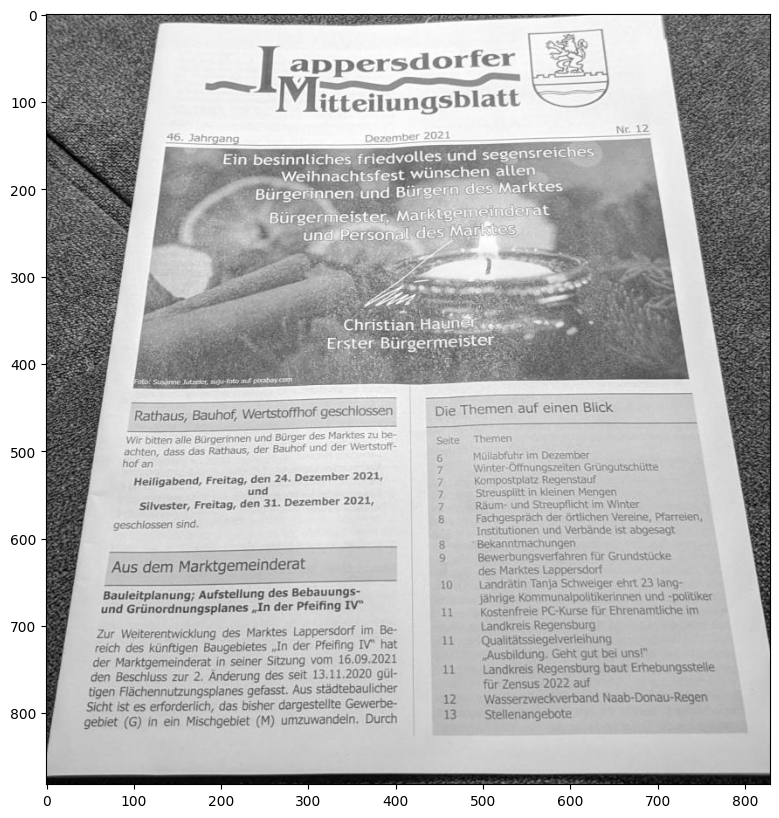

In [2]:
img = cv2.imread('data/document (1).jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img, cmap='gray')

Посмотрим на гистограмму изображения.

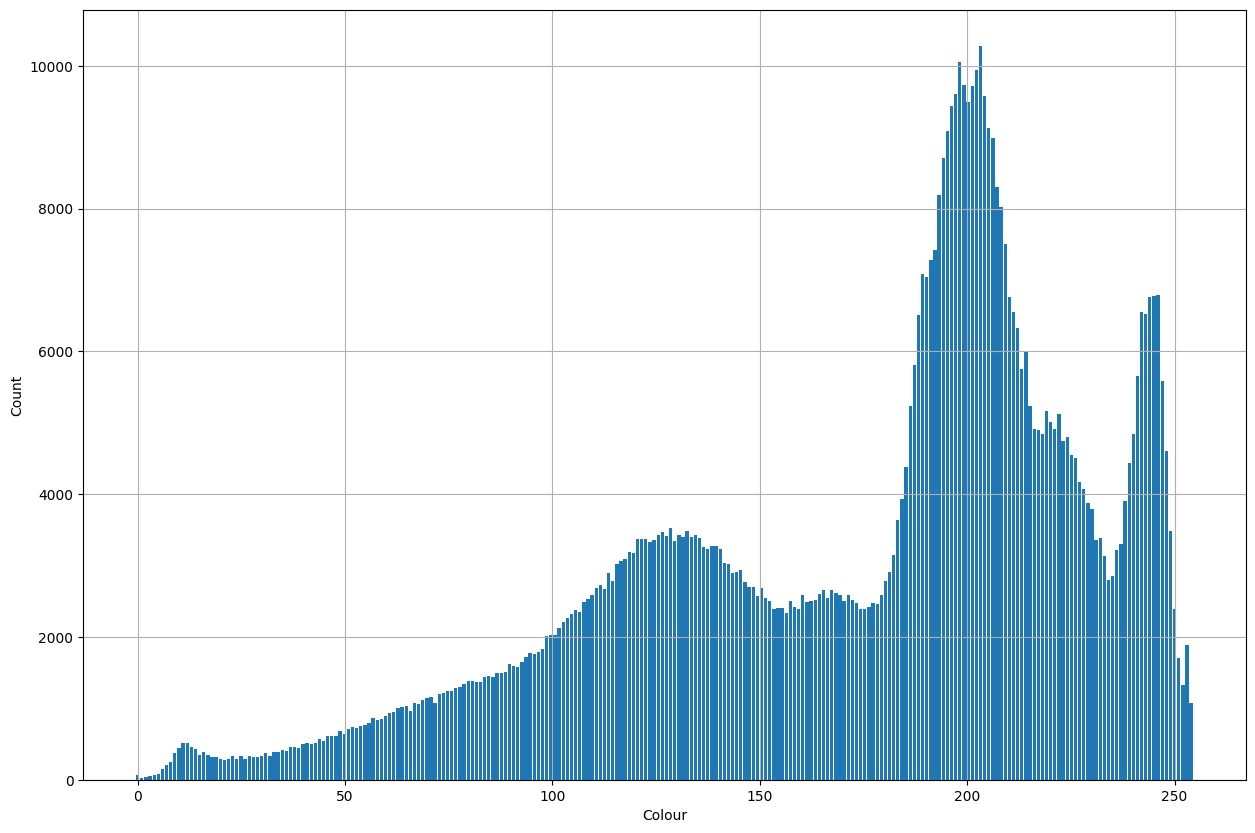

In [3]:
h = np.histogram(img, 256)
plt.bar(h[1][0:-1], h[0])
plt.xlabel('Colour'), plt.ylabel('Count')
plt.grid(True)

### Otsu Thresholding

Let's now implement the Otsu thresholding algorithm. Remember that the algorithm consists of an optimization process that finds the thresholds that minimizes the intra-class variance or, equivalently, maximizes the inter-class variance.

In this homework, you are going to demonstrate the working principle of the Otsu algorithm. Therefore, you won't have to worry about an efficient implementation, we are going to use the brute force approach here.

In [4]:
# Размеры изображения
rows, cols = img.shape
# Общее количество пикселей
num_pixels = rows * cols

# Начальные значения
best_wcv = 1e6  # лучшая внутриклассовая дисперсия
opt_th = None    # оптимальный порог

# Перебираем все возможные пороги
for th in range(0, 256):
    # Пиксели переднего плана (текст), значения <= порога
    foreground = img[img <= th]
    # Пиксели фона, значения > порога
    background = img[img > th]
    
    # Если один из классов пустой, пропускаем
    if len(foreground) == 0 or len(background) == 0:
        continue
    
    # Веса классов (omega)
    omega_f = len(foreground) / num_pixels
    omega_b = len(background) / num_pixels
    
    # Дисперсия пикселей каждого класса
    sigma2_f = np.var(foreground)
    sigma2_b = np.var(background)
    
    # Внутриклассовая дисперсия
    wcv = omega_f * sigma2_f + omega_b * sigma2_b
    
    # Если нашли дисперсию меньше, обновляем лучший результат
    if wcv < best_wcv:
        best_wcv = wcv
        opt_th = th

print('Оптимальный порог:', opt_th)

Оптимальный порог: 159


Сравним исходное изображение и результат бинаризации.

Text(0.5, 1.0, 'После бинаризации (Otsu)')

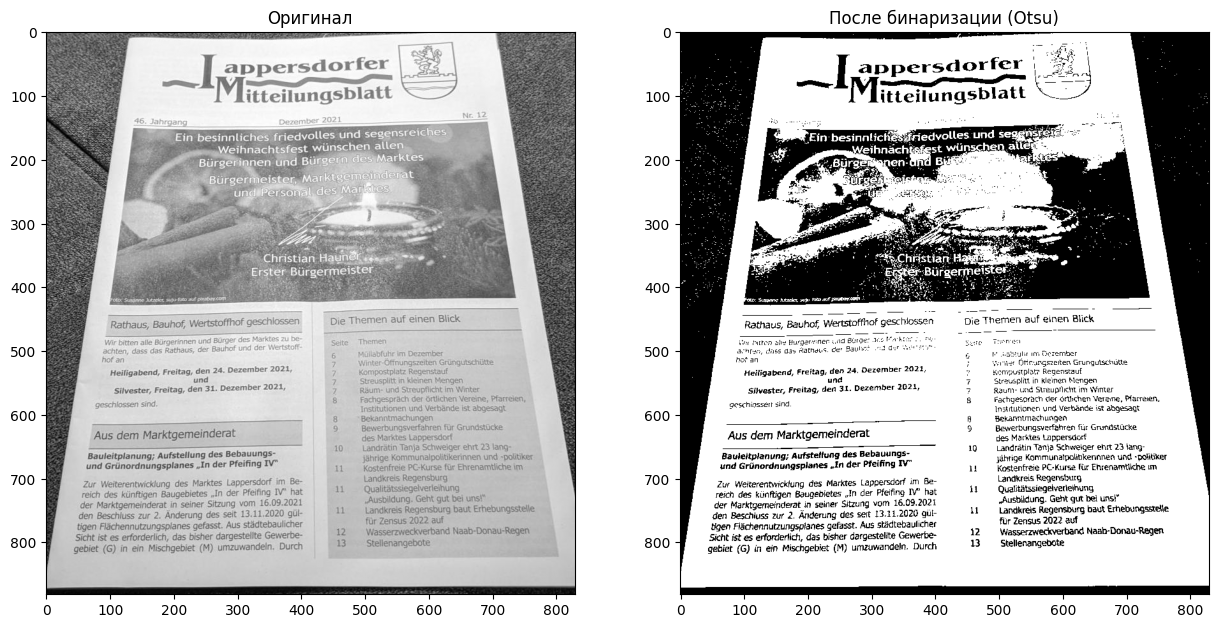

In [5]:
plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Оригинал')
plt.subplot(122), plt.imshow(img > opt_th, cmap='gray')
plt.title('После бинаризации (Otsu)')

### Ответы на вопросы

**1. Можно ли считать гистограмму бимодальной?**

Да, гистограмму можно считать бимодальной. На ней видны два основных пика: один в области темных значений (это пиксели текста), а второй в области светлых значений (это фон документа). Между ними есть провал, что характерно для бимодального распределения.

**2. Какой порог бинаризации вы бы выбрали вручную? Почему?**

Я бы выбрала порог где-то в районе 150-160, потому что это зона провала между двумя пиками гистограммы. Это значение разделяет темные пиксели текста и светлые пиксели фона. Алгоритм Otsu нашел порог 159, что совпадает с моей оценкой.

**3. Хорошо ли получилась бинаризация текста?**

Результат средний, я бы оценила на 3+. Не весь текст читается после бинаризации. Некоторые буквы теряются или сливаются, особенно там, где яркость текста близка к порогу. Скорее всего, это связано с тем, что освещение документа неравномерное, и один глобальный порог не может хорошо работать для всего изображения.